In [11]:
from nrem_sc.constants import PROCESSED_DATA_PATH, INTERIM_DATA_PATH
from nrem_sc.utils import circ_bin_average

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pynapple as nap
import seaborn as sns
import pandas as pd

from replay_trajectory_classification import SortedSpikesDecoder, SortedSpikesClassifier
from replay_trajectory_classification import make_track_graph
from replay_trajectory_classification import SortedSpikesClassifier, Environment, RandomWalk, Uniform, Identity, DiagonalDiscrete
from pycircstat2.descriptive import circ_dist
from scipy.ndimage import gaussian_filter

custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_context("notebook", font_scale=1.5, rc=custom_params)
unit_id = '116b'

def get_environment(num_nodes=360, radius=180/np.pi, place_bin_size=1.0):
    angle = np.linspace(2*np.pi, 0, num=num_nodes, endpoint=False)
    node_positions = np.stack((radius * np.cos(angle), radius * np.sin(angle)), axis=1)

    node_ids = np.arange(node_positions.shape[0])
    edges = np.stack((node_ids, np.roll(node_ids, shift=1)), axis=1)

    track_graph = make_track_graph(node_positions, edges)

    edge_spacing = 0
    n_nodes = len(track_graph.nodes)
    edge_order = np.stack((np.roll(np.arange(n_nodes-1, -1, -1), 1),
                        np.arange(n_nodes-1, -1, -1)), axis=1)

    environment = Environment(
        place_bin_size=place_bin_size,
        track_graph=track_graph,
        edge_order=edge_order,
        edge_spacing=edge_spacing
        )
    return environment
    
# Load data
sleep_states    = nap.load_file(PROCESSED_DATA_PATH / unit_id / "sleep.npz")
hd_spikes       = nap.load_file(PROCESSED_DATA_PATH / unit_id / "hd_spikes_filtered.npz")
hd_angle        = nap.load_file(PROCESSED_DATA_PATH / unit_id / "angle_openfield.npz")
sessions        = nap.load_file(PROCESSED_DATA_PATH / unit_id / "sessions_labeled.npz")

## Testing SortedSpikesDecoder on Wake data

In [ ]:
bin_size = 1

ep = nap.IntervalSet([17000], [18000])
spikes = hd_spikes.count(bin_size=bin_size, ep=ep, time_units='ms').astype(np.bool)
angle = circ_bin_average(tsd=hd_angle, bin_size=bin_size, ep=ep, time_units='ms').to_numpy()

t, spikes = spikes.times(), spikes.to_numpy()

# 80% training, 20% testing
is_training = np.ones_like(angle, dtype=bool)
is_training[int(len(angle)*0.8):] = False

(1000000,)

In [3]:
movement_var = 2.0 * bin_size
place_bin_size = 1.0

environment = get_environment(place_bin_size=place_bin_size)

decoder = SortedSpikesDecoder(
    environment=environment,
    transition_type=RandomWalk(movement_var=movement_var)
)

decoder.fit(angle, spikes, is_training=is_training)

c:\Users\iii9781\nrem_sc\.venv\Lib\site-packages\replay_trajectory_classification\likelihoods\spiking_likelihood_kde.py:119: RuntimeWarning: divide by zero encountered in log
  return np.exp(np.log(mean_rate) + np.log(marginal_density) - np.log(occupancy))


,environment,Environment(e...t_threshold=0)
,transition_type,RandomWalk(en...ffusion=False)
,initial_conditions_type,UniformInitialConditions()
,infer_track_interior,True
,sorted_spikes_algorithm,'spiking_likelihood_kde'
,sorted_spikes_algorithm_params,"{'block_size': None, 'position_std': 6.0, 'use_diffusion': False}"


In [4]:
decoded = decoder.predict(spikes[~is_training])

  0%|          | 0/81 [00:00<?, ?it/s]

c:\Users\iii9781\nrem_sc\.venv\Lib\site-packages\replay_trajectory_classification\core.py:87: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 2, 'F', False, aligned=True), Array(float64, 1, 'A', False, aligned=True))
  posterior[k] = state_transition.T @ posterior[k - 1] * likelihood[k]
c:\Users\iii9781\nrem_sc\.venv\Lib\site-packages\replay_trajectory_classification\core.py:119: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 2, 'F', False, aligned=True), Array(float64, 2, 'A', False, aligned=True))
  acausal_prior = state_transition.T @ causal_posterior[time_ind]


In [7]:
feature = decoded.acausal_posterior
feature = gaussian_filter(feature, sigma=1)

decoded_max = decoded.acausal_posterior.idxmax(dim="position").to_numpy()
true = angle[~is_training]
times = t[~is_training]

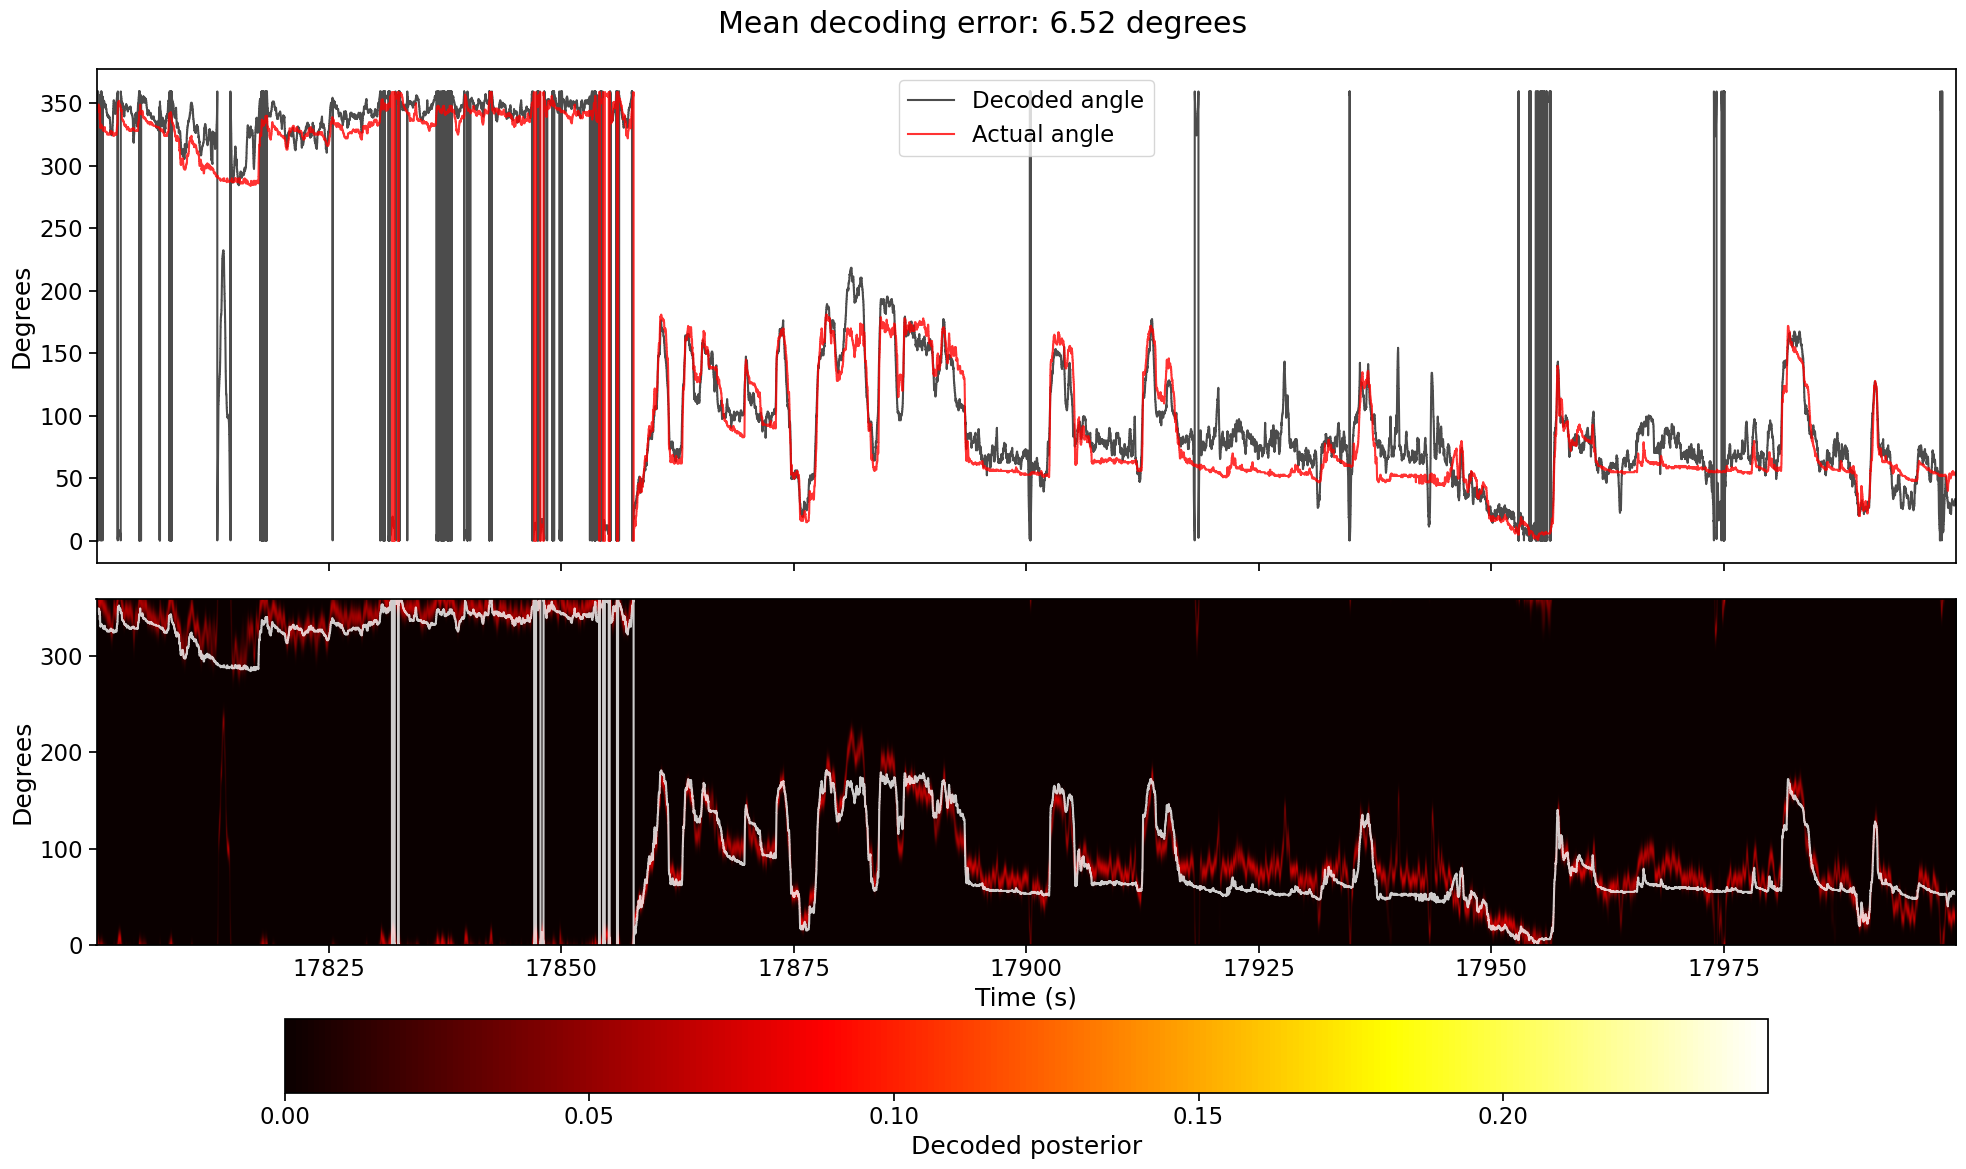

In [17]:
error = circ_dist(np.deg2rad(decoded_max), np.deg2rad(true), metric='center').mean() * 180/np.pi

fig, axes = plt.subplots(2, 1, figsize=(20, 12), sharex=True)

axes[0].plot(times, decoded_max, label='Decoded angle', color='k', alpha=0.7)
axes[0].plot(times, true, label='Actual angle', color='r', alpha=0.8)
axes[0].set_ylabel('Degrees')
axes[0].legend()

im = axes[1].imshow(feature.T,
        aspect='auto',
        interpolation='bilinear',
        extent=[times[0], times[-1], true.min(), true.max()],
        origin='lower',
        cmap='hot',
        )
axes[1].plot(times, true, label='Actual angle', color='white', alpha=0.8, linewidth=1.5)
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Degrees')
fig.colorbar(im, ax=axes[1], orientation='horizontal', label='Decoded posterior')

fig.suptitle(f'Mean decoding error: {error:.2f} degrees')
plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(20, 3))
(decoder.place_fields_[('',0)] * 1000).plot(x="position", hue="neuron", add_legend=False, ax=ax)
ax.set_xlabel('Linear Position')
ax.set_ylabel('Firing Rate')
plt.show()

## Tuning SortedSpikesClassifier parameters

In [12]:
bin_size = 1
p_state = 0.99
movement_var = 2.0 * bin_size
place_bin_size = 1.0
openfield_epochs = nap.IntervalSet([17000], [18000]) # Openfield session
nrem_epochs = nap.IntervalSet(start=[35400], end=[35600])

# Bin the spikes and angle data
spikes = hd_spikes.count(bin_size=bin_size, ep=openfield_epochs, time_units='ms').astype(np.bool)
sleep_spikes = hd_spikes.restrict(nrem_epochs).count(bin_size=bin_size, time_units='ms').astype(np.bool)
angle = circ_bin_average(tsd=hd_angle, bin_size=bin_size, ep=openfield_epochs, time_units='ms')

# Circular environment with 360 bins for head direction
environment = get_environment(place_bin_size=place_bin_size)
continuous_transition_types = [[RandomWalk(movement_var=movement_var),  Uniform(), Identity()],
                                [Uniform(),                    Uniform(), Uniform()],
                                [RandomWalk(movement_var=movement_var), Uniform(), Identity()]]
classifier = SortedSpikesClassifier(
    environments=environment,
    continuous_transition_types=continuous_transition_types,
    discrete_transition_type=DiagonalDiscrete(p_state),
)

# Fit on the whole openfield session
classifier.fit(position=angle.to_numpy(), spikes=spikes.to_numpy())
decoded = classifier.predict(sleep_spikes.values, time=sleep_spikes.times(), state_names=['continuous', 'fragmented', 'stationary'])

c:\Users\iii9781\nrem_sc\.venv\Lib\site-packages\replay_trajectory_classification\likelihoods\spiking_likelihood_kde.py:119: RuntimeWarning: divide by zero encountered in log
  return np.exp(np.log(mean_rate) + np.log(marginal_density) - np.log(occupancy))


  0%|          | 0/81 [00:00<?, ?it/s]

In [3]:
min_gap = 100  # Minimum gap between sweeps in ms
sweep_threshold = 0.55 

# Extract probabilities and most likely state
prob_state = decoded.acausal_posterior.sum(dim="position").to_numpy() # Shape (N, 3)
pos_max = decoded.acausal_posterior.sum(dim="state").idxmax(dim="position").to_numpy() # Shape (N,)
time = decoded['time'].to_numpy()

time = time - time[0]  # Shift time to start at 0

tsd = nap.Tsd(t=time, d=pos_max)
tdf = nap.TsdFrame(t=time, d=prob_state, columns=['continuous', 'fragmented', 'stationary'])

# Sweeps thresholding
tsdf = tdf.as_dataframe()
tsdf['state'] = np.where(tsdf.max(axis=1) > sweep_threshold, tsdf.idxmax(axis=1), 'mixture')
sweep_eps = nap.TsdFrame(tsdf[tsdf['state'] == 'continuous']).find_support(min_gap, 'ms')

# Shift spike times to start at 0
spks = hd_spikes.restrict(nrem_epochs)
start_time = spks.time_support['start'][0]
shifted = {}
for k, v in spks.data.items():
    v_new = nap.Ts(t = np.array(v.as_series().index) - start_time)
    shifted[k] = v_new
shifted = nap.TsGroup(shifted, metadata=spks.metadata.drop(columns=['rate']))

print(f"Average time spent in state per bin: {2/(1-p_state):.2f} ms")
print(f"Start: {time[0]:.2f} s, End: {time[-1]:.2f} s, Duration: {(time[-1]-time[0]):.2f} s")
print(f"Detected {len(sweep_eps)} sweeps with threshold {sweep_threshold*100:.1f}% and min gap {min_gap} ms")

Average time spent in state per bin: 200.00 ms
Start: 0.00 s, End: 200.00 s, Duration: 200.00 s
Detected 133 sweeps with threshold 55.0% and min gap 100 ms


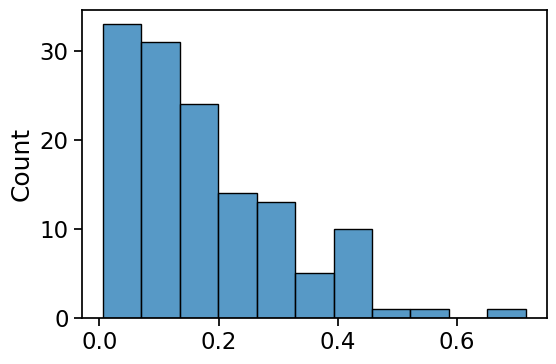

In [4]:
durations = sweep_eps['end'] - sweep_eps['start']

fig, ax = plt.subplots(figsize=(6, 4))
ax = sns.histplot(durations, ax=ax)

In [5]:
pref_angle = shifted['preferred_angle'].apply(np.rad2deg)
# Normalizes data into the range [0,1]
norm = plt.Normalize()
# Assigns a color in the HSV colormap for each value of preferred angle
color = plt.cm.hsv(norm([i / (2 * np.pi) for i in pref_angle.values]))

In [6]:
eps = nap.TsdFrame(tsdf[tsdf['state'] == 'continuous']).find_support(min_gap, 'ms')
eps

index    start    end
0        3.896    3.955001
1        4.783    5.110001
2        8.359    8.814001
3        11.146   11.158001
4        13.329   13.897001
5        14.793   14.823001
6        14.972   15.096001
...      ...      ...
126      192.813  192.850001
127      194.175  194.260001
128      194.417  194.453001
129      194.938  195.358001
130      196.857  196.963001
131      197.265  197.562001
132      197.961  197.992001
shape: (133, 2), time unit: sec.

In [7]:
sweep_eps = sweep_eps.drop_short_intervals(0.2)

In [ ]:
%matplotlib ipympl
fig, ax = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# state probabilities
ax[0].plot(tdf.times(), tdf['continuous'], label='Continuous', color='tab:blue')
ax[0].plot(tdf.times(), tdf['fragmented'], label='Fragmented', color='tab:orange')
ax[0].plot(tdf.times(), tdf['stationary'], label='Stationary', color='tab:green')
ax[0].axhline(sweep_threshold, color='r', linestyle='--', linewidth=1, label=f'Threshold ({sweep_threshold})')
ax[0].set_ylim(0, 1)
ax[0].set_ylabel('Probability')
ax[0].set_title('State Probabilities')
ax[0].legend(loc='upper right')
ax[0].grid(axis='y', alpha=0.3)

# decoded position + spike raster
ax[1].plot(tsd, label='Decoded Position', color='gray', alpha=0.8, linestyle='--')
ax[1].set_xlabel('Time (s)')
ax[1].set_ylabel('Position (°)')
ax[1].set_title('Decoded Position & Spike Raster')
ax[1].hlines([0, 359], color='k', xmin=tdf.times().min(), xmax=tdf.times().max(), linestyle='--', linewidth=0.5)

for i, n in enumerate(shifted.keys()):
    ax[1].plot(shifted[n].fillna(pref_angle[n].item()), '|', color=color[i], markersize=10)

# Highlight detected sweep epochs
for ep in sweep_eps:
    for a in ax:
        a.axvspan(ep['start'].item(), ep['end'].item(), color='cyan', alpha=0.2)

# for a in ax:
#     a.set_xlim(70, 80)

plt.tight_layout()
plt.show()

In [87]:
sweep_eps.intersect(nap.IntervalSet((61, 64)))

  index    start     end
      0   61.619  62.234
      1   62.276  62.524
shape: (2, 2), time unit: sec.

In [70]:
tdf[166*1000:167*1000]

Time (s)      continuous    fragmented    stationary
----------  ------------  ------------  ------------
166.0           0.459635    0.00447352      0.535891
166.001         0.459753    0.00447897      0.535768
166.002         0.459885    0.0044843       0.53563
166.003         0.460034    0.00448953      0.535476
166.004         0.4602      0.00449465      0.535306
166.005         0.460367    0.00453167      0.535101
166.006         0.460539    0.00456712      0.534894
...
166.993         0.507718    0.00597745      0.486305
166.994         0.507386    0.00682622      0.485788
166.995         0.505944    0.0104429       0.483614
166.996         0.504425    0.0141721       0.481403
166.997         0.502826    0.0180225       0.479151
166.998         0.501144    0.0220028       0.476853
166.999         0.499375    0.0261221       0.474503
dtype: float64, shape: (1000, 3)